<a href="https://colab.research.google.com/github/atletisimo/-_-_-/blob/main/risk_anomalies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import os
import networkx as nx
path = kagglehub.dataset_download("aryan208/cybersecurity-threat-detection-logs")

Using Colab cache for faster access to the 'cybersecurity-threat-detection-logs' dataset.


ИМПОРТИРАЊЕ НА БИБЛИОТЕКИТЕ

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import confusion_matrix
import networkx as nx
from networkx import pagerank
import warnings


warnings.filterwarnings('ignore')
import xgboost as xgb

LOADING AND PREPROCESSING

In [13]:
# ===============================
# LOADING AND PREPROCESSING DATA
# ===============================
print("="*80)
print("LOADING AND PREPROCESSING DATA")
print("="*80)
csv_file = os.path.join(path, "cybersecurity_threat_detection_logs.csv")

df = pd.read_csv(csv_file)


print("\nБрој на редици:", df.shape[0])
print("Број на колони:", df.shape[1])
print("\nПрви 5 редици:\n", df.head())
print("\nПодатоци за dataset-от:\n")
print(df.info())




df['timestamp'] = pd.to_datetime(df['timestamp'])

print("\nTimestamp column converted to datetime:")
display(df[['timestamp']].head())
df.info()



unique_ips = pd.concat([df['source_ip'], df['dest_ip']]).unique()
num_unique_ips = len(unique_ips)

print(f"\nTotal number of unique IP addresses (potential graph nodes): {num_unique_ips}")
print("Example unique IPs:", unique_ips[:5])


le = LabelEncoder()


categorical_cols_for_encoding = [
    'protocol',
    'action',
    'threat_label',
    'log_type',
    'user_agent',
    'request_path'
]

for col in categorical_cols_for_encoding:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])
        print(f"Column '{col}' encoded. Unique values after encoding: {df[col].unique()}")

print("\nDataFrame after Label Encoding:")
display(df.head())
df.info()


X = df.drop('threat_label', axis=1)
y = df['threat_label']

print(f"\nShape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

LOADING AND PREPROCESSING DATA

Број на редици: 6000000
Број на колони: 10

Први 5 редици:
              timestamp      source_ip        dest_ip protocol   action  \
0  2024-05-01T00:00:00  192.168.1.125  192.168.1.124      TCP  blocked   
1  2024-07-18T00:00:00  192.168.1.201  192.168.1.201     ICMP  blocked   
2  2024-04-07T00:00:00  192.168.1.248   192.168.1.15     HTTP  allowed   
3  2024-10-26T00:00:00  192.168.1.236  192.168.1.219     HTTP  allowed   
4  2024-10-31T00:00:00  192.168.1.221   192.168.1.61     ICMP  allowed   

  threat_label     log_type  bytes_transferred  \
0       benign     firewall              10889   
1       benign  application              36522   
2       benign  application              20652   
3       benign  application               5350   
4       benign  application              40691   

                                          user_agent request_path  
0                              Nmap Scripting Engine            /  
1                         

,timestamp
0,2024-05-01
1,2024-07-18
2,2024-04-07
3,2024-10-26
4,2024-10-31


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000000 entries, 0 to 5999999
Data columns (total 10 columns):
 #   Column             Dtype         
---  ------             -----         
 0   timestamp          datetime64[ns]
 1   source_ip          object        
 2   dest_ip            object        
 3   protocol           object        
 4   action             object        
 5   threat_label       object        
 6   log_type           object        
 7   bytes_transferred  int64         
 8   user_agent         object        
 9   request_path       object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 457.8+ MB

Total number of unique IP addresses (potential graph nodes): 354
Example unique IPs: ['192.168.1.125' '192.168.1.201' '192.168.1.248' '192.168.1.236'
 '192.168.1.221']
Column 'protocol' encoded. Unique values after encoding: [5 3 1 0 6 2 4]
Column 'action' encoded. Unique values after encoding: [1 0]
Column 'threat_label' encoded. Unique values 

,timestamp,source_ip,dest_ip,protocol,action,threat_label,log_type,bytes_transferred,user_agent,request_path
0,2024-05-01,192.168.1.125,192.168.1.124,5,1,0,1,10889,2,0
1,2024-07-18,192.168.1.201,192.168.1.201,3,1,0,0,36522,2,0
2,2024-04-07,192.168.1.248,192.168.1.15,1,0,0,0,20652,1,168
3,2024-10-26,192.168.1.236,192.168.1.219,1,0,0,0,5350,0,168
4,2024-10-31,192.168.1.221,192.168.1.61,3,0,0,0,40691,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000000 entries, 0 to 5999999
Data columns (total 10 columns):
 #   Column             Dtype         
---  ------             -----         
 0   timestamp          datetime64[ns]
 1   source_ip          object        
 2   dest_ip            object        
 3   protocol           int64         
 4   action             int64         
 5   threat_label       int64         
 6   log_type           int64         
 7   bytes_transferred  int64         
 8   user_agent         int64         
 9   request_path       int64         
dtypes: datetime64[ns](1), int64(7), object(2)
memory usage: 457.8+ MB

Shape of X (features): (6000000, 9)
Shape of y (target): (6000000,)

Shape of X_train: (4800000, 9)
Shape of X_test: (1200000, 9)
Shape of y_train: (4800000,)
Shape of y_test: (1200000,)


АНОМАЛИИ И РИЗИЧНИ ТОЧКИ

In [14]:
print("====================================================")
print("КРЕИРАЊЕ НА ГРАФ")
print("====================================================")

G = nx.DiGraph()

edge_counts = df.groupby(['source_ip', 'dest_ip']).size().reset_index(name='weight')


for index, row in edge_counts.iterrows():
    G.add_edge(row['source_ip'], row['dest_ip'], weight=row['weight'])

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

print("====================================================")
print("STEP 2: NODE FEATURES (GRAPH-BASED)")
print("====================================================")


degree = dict(G.degree())
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
weighted_degree = dict(G.degree(weight='weight'))




#  Betweenness Centrality

print("Calculating Betweenness Centrality...")
betweenness_centrality = nx.betweenness_centrality(G, weight='weight', k=min(G.number_of_nodes(), 500), seed=42)

print("Calculating Closeness Centrality...")
closeness_centrality = nx.closeness_centrality(G, distance='weight')

print("Calculating PageRank...")
pagerank_scores = nx.pagerank(G, weight='weight')


node_features = pd.DataFrame({
    'degree': pd.Series(degree),
    'in_degree': pd.Series(in_degree),
    'out_degree': pd.Series(out_degree),
    'weighted_degree': pd.Series(weighted_degree),
    'betweenness_centrality': pd.Series(betweenness_centrality),
    'closeness_centrality': pd.Series(closeness_centrality),
    'pagerank': pd.Series(pagerank_scores)
}).fillna(0)

print("Node features extracted:")
display(node_features.head())

print("====================================================")
print("ДЕТЕКЦИЈА НА АНОМАЛИИ")
print("====================================================")


scaler = StandardScaler()
X_scaled = scaler.fit_transform(node_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=node_features.columns, index=node_features.index)

print("Applying Isolation Forest...")
# Isolation Forest
iso_forest = IsolationForest(random_state=42, contamination='auto')
iso_forest_predictions = iso_forest.fit_predict(X_scaled)
iso_forest_scores = iso_forest.decision_function(X_scaled)

node_features['iso_forest_anomaly_label'] = iso_forest_predictions
node_features['iso_forest_anomaly_score'] = iso_forest_scores

# Convert -1 (outliers) to 1 (anomaly) and 1 (inliers) to 0 (normal)
node_features['iso_forest_anomaly_label'] = node_features['iso_forest_anomaly_label'].apply(lambda x: 1 if x == -1 else 0)

print("Applying Local Outlier Factor (LOF)...")
# (LOF)
lof = LocalOutlierFactor(contamination='auto', novelty=False, n_jobs=-1)
lof_predictions = lof.fit_predict(X_scaled)
lof_scores = lof.negative_outlier_factor_

node_features['lof_anomaly_label'] = lof_predictions
node_features['lof_anomaly_score'] = -lof_scores # LOF scores are negative, higher absolute value means more anomalous

# Convert -1 (outliers) to 1 (anomaly) and 1 (inliers) to 0 (normal)
node_features['lof_anomaly_label'] = node_features['lof_anomaly_label'].apply(lambda x: 1 if x == -1 else 0)

print("Anomaly Detection Results:")
display(node_features[['iso_forest_anomaly_label', 'iso_forest_anomaly_score',
                       'lof_anomaly_label', 'lof_anomaly_score']].head())

# ТОП 10
print("Top 10 most anomalous IPs by Isolation Forest score:")
most_anomalous_iso = node_features.sort_values(by='iso_forest_anomaly_score', ascending=True).head(10)
display(most_anomalous_iso[['iso_forest_anomaly_label', 'iso_forest_anomaly_score']])

print("Top 10 most anomalous IPs by LOF score:")
most_anomalous_lof = node_features.sort_values(by='lof_anomaly_score', ascending=False).head(10)
display(most_anomalous_lof[['lof_anomaly_label', 'lof_anomaly_score']])

print("====================================================")
print(" RISK ANALYSIS")
print("====================================================")

risk_features = node_features[['pagerank', 'betweenness_centrality', 'degree', 'weighted_degree']]
min_max_scaler = MinMaxScaler()
risk_features_scaled = min_max_scaler.fit_transform(risk_features)
risk_features_scaled_df = pd.DataFrame(risk_features_scaled, columns=risk_features.columns, index=node_features.index)

# Calculate risk score with the new weighted formula

node_features['risk_score'] = (
    0.4 * risk_features_scaled_df['pagerank'] +
    0.3 * risk_features_scaled_df['betweenness_centrality'] +
    0.2 * risk_features_scaled_df['weighted_degree'] +
    0.1 * risk_features_scaled_df['degree']
)

# Rank IPs by risk score
ranked_risky_ips = node_features.sort_values(by='risk_score', ascending=False)

print("Топ 10 ризични IP адреси со ажуриран ризик-скор:")
display(ranked_risky_ips[['risk_score', 'pagerank', 'betweenness_centrality', 'degree', 'weighted_degree']].head(10))

print("Top 10 risky IP addresses:")
display(ranked_risky_ips[['risk_score', 'pagerank', 'betweenness_centrality', 'degree', 'weighted_degree']].head(10))

print("Explanation for top risky IPs:")
for ip, row in ranked_risky_ips.head(10).iterrows():
    print(f"\nIP: {ip}")
    print(f"  Risk Score: {row['risk_score']:.4f}")
    print(f"  - High PageRank ({row['pagerank']:.4f}): Indicates this IP is frequently accessed or communicates with important nodes.")
    print(f"  - High Betweenness Centrality ({row['betweenness_centrality']:.4f}): Suggests this IP acts as a bridge or a critical point in communication paths.")
    print(f"  - High Degree ({row['degree']:.0f}): Implies this IP has many connections, potentially interacting with numerous other IPs.")
    print(f"  - High Weighted Degree ({row['weighted_degree']:.0f}): Shows high volume or frequency of communication with other IPs.")
    print("  In a cybersecurity context, IPs with high scores in these metrics could be:")
    print("  - Command and Control (C2) servers if they are destination IPs with high PageRank and weighted degree.")
    print("  - Pivoting points for attacks if they have high betweenness centrality.")
    print("  - Servers experiencing DoS/DDoS attacks (high in-degree) or performing scans/attacks (high out-degree).")
    print("  - Critical assets that, if compromised, could impact a large part of the network.")

КРЕИРАЊЕ НА ГРАФ
Graph created with 354 nodes and 89916 edges.
STEP 2: NODE FEATURES (GRAPH-BASED)
Calculating Betweenness Centrality...
Calculating Closeness Centrality...
Calculating PageRank...
Node features extracted:


,degree,in_degree,out_degree,weighted_degree,betweenness_centrality,closeness_centrality,pagerank
103.172.167.96,254,0,254,18126,0.0,0.000000,0.000424
192.168.1.1,608,354,254,40240,0.0,0.014984,0.003763
192.168.1.10,608,354,254,40588,0.0,0.014840,0.003793
192.168.1.100,608,354,254,40484,0.0,0.014941,0.003797
192.168.1.101,608,354,254,40419,0.0,0.014888,0.003811


ДЕТЕКЦИЈА НА АНОМАЛИИ
Applying Isolation Forest...
Applying Local Outlier Factor (LOF)...
Anomaly Detection Results:


,iso_forest_anomaly_label,iso_forest_anomaly_score,lof_anomaly_label,lof_anomaly_score
103.172.167.96,1,-0.036333,0,1.056499
192.168.1.1,0,0.127114,0,1.022544
192.168.1.10,0,0.012917,0,1.283417
192.168.1.100,0,0.064459,0,1.096622
192.168.1.101,0,0.062647,0,1.060597


Top 10 most anomalous IPs by Isolation Forest score:


...

 RISK ANALYSIS
Топ 10 ризични IP адреси со ажуриран ризик-скор:


,risk_score,pagerank,betweenness_centrality,degree,weighted_degree
192.168.1.59,0.989082,0.003810,0.000020,608,40201
192.168.1.146,0.982532,0.003760,0.000020,608,40112
192.168.1.129,0.866031,0.003782,0.000012,608,40219
192.168.1.42,0.863207,0.003787,0.000012,608,39826
192.168.1.249,0.809386,0.003790,0.000008,608,40511
192.168.1.44,0.809314,0.003797,0.000008,608,40404
192.168.1.72,0.809097,0.003808,0.000008,608,40223
192.168.1.176,0.805113,0.003792,0.000008,608,39983
192.168.1.196,0.804233,0.003767,0.000008,608,40214
192.168.1.115,0.801835,0.003768,0.000008,608,39934


Top 10 risky IP addresses:


,risk_score,pagerank,betweenness_centrality,degree,weighted_degree
192.168.1.59,0.989082,0.003810,0.000020,608,40201
192.168.1.146,0.982532,0.003760,0.000020,608,40112
192.168.1.129,0.866031,0.003782,0.000012,608,40219
192.168.1.42,0.863207,0.003787,0.000012,608,39826
192.168.1.249,0.809386,0.003790,0.000008,608,40511
192.168.1.44,0.809314,0.003797,0.000008,608,40404
192.168.1.72,0.809097,0.003808,0.000008,608,40223
192.168.1.176,0.805113,0.003792,0.000008,608,39983
192.168.1.196,0.804233,0.003767,0.000008,608,40214
192.168.1.115,0.801835,0.003768,0.000008,608,39934


Explanation for top risky IPs:

IP: 192.168.1.59
  Risk Score: 0.9891
  - High PageRank (0.0038): Indicates this IP is frequently accessed or communicates with important nodes.
  - High Betweenness Centrality (0.0000): Suggests this IP acts as a bridge or a critical point in communication paths.
  - High Degree (608): Implies this IP has many connections, potentially interacting with numerous other IPs.
  - High Weighted Degree (40201): Shows high volume or frequency of communication with other IPs.
  In a cybersecurity context, IPs with high scores in these metrics could be:
  - Command and Control (C2) servers if they are destination IPs with high PageRank and weighted degree.
  - Pivoting points for attacks if they have high betweenness centrality.
  - Servers experiencing DoS/DDoS attacks (high in-degree) or performing scans/attacks (high out-degree).
  - Critical assets that, if compromised, could impact a large part of the network.

IP: 192.168.1.146
  Risk Score: 0.9825
  - High

ВИЗУЕЛИЗАЦИЈА



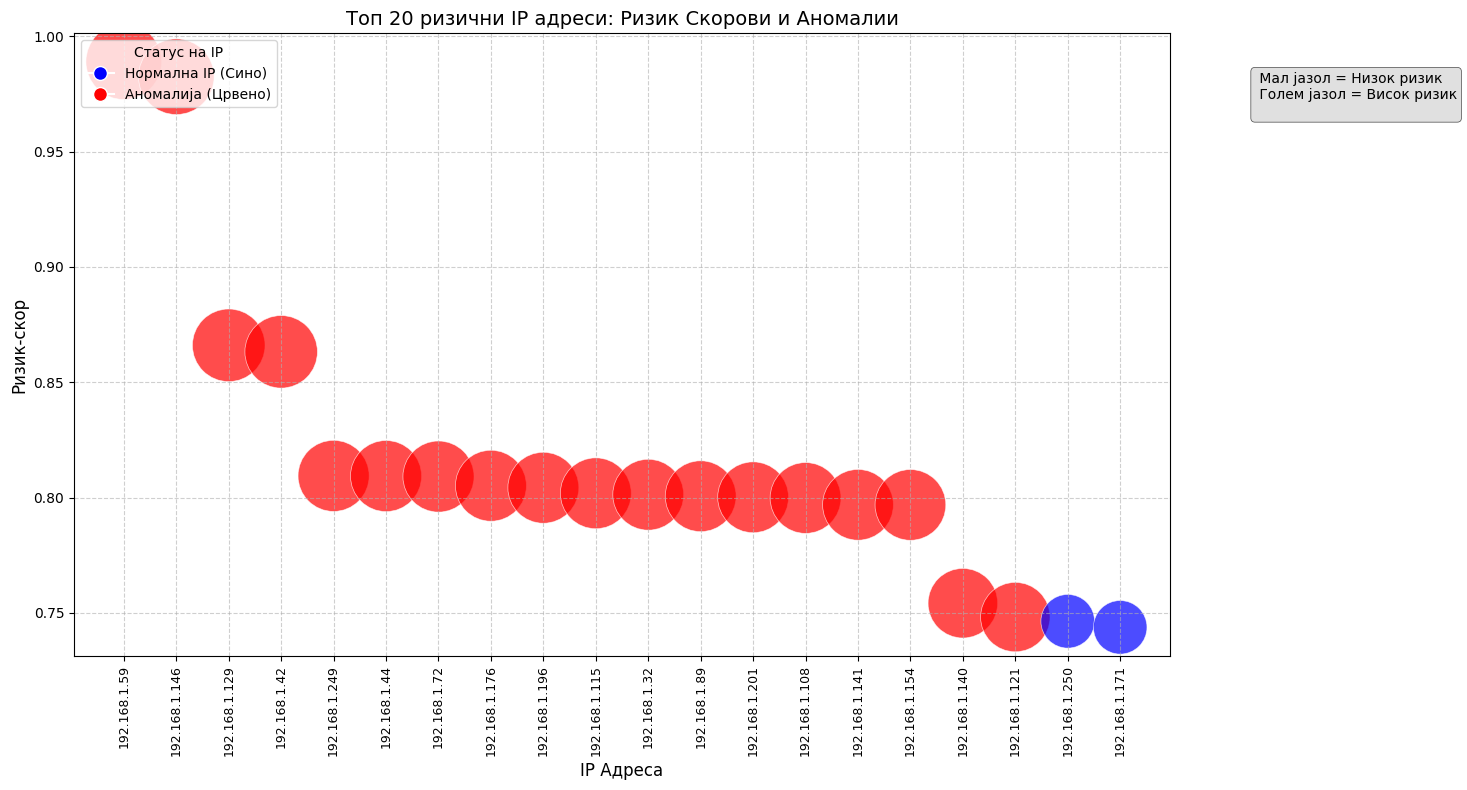

In [15]:

import matplotlib.pyplot as plt

top20_risky_ips = ranked_risky_ips.head(20)


#  (0: normal, 1: anomaly)
anomaly_labels = top20_risky_ips['iso_forest_anomaly_label']
risk_scores = top20_risky_ips['risk_score']


colors = anomaly_labels.map({0: 'blue', 1: 'red'})


base_size_factor = 2000
anomaly_size_boost_factor = 1000
sizes = (risk_scores * base_size_factor) + (anomaly_labels * anomaly_size_boost_factor)


plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    x=range(len(top20_risky_ips)),
    y=risk_scores,
    s=sizes,
    c=colors,
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)

plt.xticks(range(len(top20_risky_ips)), top20_risky_ips.index, rotation=90, fontsize=9)

plt.xlabel("IP Адреса", fontsize=12)
plt.ylabel("Ризик-скор", fontsize=12)
plt.title("Топ 20 ризични IP адреси: Ризик Скорови и Аномалии", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)


legend_elements_color = [
    plt.Line2D([0], [0], marker='o', color='w', label='Нормална IP (Сино)',
               markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Аномалија (Црвено)',
               markerfacecolor='red', markersize=10)
]

plt.legend(handles=legend_elements_color, title="Статус на IP", loc='upper left')


plt.figtext(0.9, 0.85,
            " Мал јазол = Низок ризик\n"
            " Голем јазол = Висок ризик\n"
           ,
            bbox=dict(boxstyle="round,pad=0.3", fc="lightgrey", ec="black", lw=0.5, alpha=0.7),
            fontsize=10, ha='left')


plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()